# [7.2] Feature Verbalizers - Solutions

By the end of this notebook, you will have shown that a concise feature verbalizer only deserves belief when it predicts held-out counterfactual activations and the sign of a feature-direction intervention, because a revised semantic rule beats text-only, random-word, and example-lookup controls on an exact planted feature before we escalate to a pinned `gelu-1l` residual direction.

Feature verbalizers are a tempting trap. You look at top activating examples, write a phrase that sounds right, and feel like you understand the feature. The ARENA move is to make that phrase predict something: bottom examples, random examples, near-misses, held-out counterfactuals, and interventions.

```python
GT_TIER = "GT-1"
EXERCISE_ID = "7_2_feature_verbalizers"
EXPECTED_RUNTIME = "60-90 minutes for CPU exercises; several minutes for parent CUDA gelu-1l preflight"
REQUIRES_GPU = True
```

## Core Question

When does a concise natural-language feature description predict held-out activations and causal intervention effects rather than merely summarize its top examples?

## Learning Objectives

- Build a planted feature with exact semantic ground truth and known counterexamples.
- Gather top, bottom, random, and contrastive examples without losing labels or scores.
- Convert a natural-language explanation into an executable prediction rule.
- Mine failures, revise the explanation, and test the revision on examples you did not use for revision.
- Compare against text-only, random-keyword, train-example lookup, and activation-score controls.
- Test whether the verbalizer predicts the sign of a feature-direction intervention.
- Inspect the pinned real-transformer escalation path without treating it as the main proof.

The planted feature in this notebook fires for: `living animal + resting verb + physical surface - decoy object terms`. The counterexamples are deliberate: toy cats, plush dogs, statues, moving animals, objects resting on surfaces, and substring traps such as `catalog`.


## Setup

Run this cell first. It defines the dataclasses, semantic lexicon, and finite prompt list. The exact rule is not hidden in a model; your job is to implement it, then use it as a ground-truth oracle for the verbalizer loop.


In [1]:
import re
import json
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
from IPython.display import display

chapter = "chapter7_activation_to_language"
section = "part2_feature_verbalizers"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section

if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
if str(exercises_dir) not in sys.path:
    sys.path.append(str(exercises_dir))

import part2_feature_verbalizers.tests as tests

ExampleKind = Literal["top", "bottom", "random", "contrastive"]
SplitKind = Literal["train", "revision", "heldout"]

TOKEN_RE = re.compile(r"[a-zA-Z]+")

DEFAULT_STOPWORDS = {
    "a",
    "an",
    "and",
    "at",
    "beside",
    "by",
    "during",
    "in",
    "near",
    "of",
    "on",
    "over",
    "the",
    "to",
}

ANIMAL_TERMS = frozenset(
    {
        "alpaca",
        "badger",
        "bear",
        "cat",
        "dog",
        "fox",
        "goat",
        "horse",
        "kitten",
        "lizard",
        "mouse",
        "otter",
        "owl",
        "puppy",
        "rabbit",
        "seal",
        "sheep",
    }
)

RESTING_TERMS = frozenset(
    {"curled", "dozed", "lounged", "napped", "perched", "rested", "roosted", "sat", "slept"}
)

SURFACE_TERMS = frozenset(
    {
        "basket",
        "bench",
        "blanket",
        "branch",
        "couch",
        "dock",
        "fence",
        "floor",
        "hay",
        "ledge",
        "log",
        "mat",
        "mound",
        "pillow",
        "rock",
        "rug",
        "shelf",
        "sofa",
        "table",
    }
)

DECOY_TERMS = frozenset({"cardboard", "ceramic", "painted", "plastic", "plush", "statue", "toy", "wooden"})

DEFAULT_SEMANTIC_LEXICON = {
    "animal": ANIMAL_TERMS,
    "resting": RESTING_TERMS,
    "surface": SURFACE_TERMS,
    "decoy": DECOY_TERMS,
}

_PLANTED_EXAMPLE_SPECS: tuple[tuple[str, SplitKind, str], ...] = (
    ("The cat sat on the mat.", "train", "positive"),
    ("A dog slept on the rug.", "train", "positive"),
    ("The rabbit rested near the sofa.", "train", "positive"),
    ("An otter napped on the dock.", "train", "positive"),
    ("The goat lounged beside the bench.", "train", "positive"),
    ("A fox perched on the ledge.", "train", "positive"),
    ("The robot rested on the sofa.", "train", "object_resting"),
    ("The book rested on the shelf.", "train", "object_resting"),
    ("The cat sprinted across the mat.", "train", "animal_motion"),
    ("The dog slept during the storm.", "train", "no_surface"),
    ("The kite floated above the field.", "train", "irrelevant"),
    ("The lamp sat on the floor.", "train", "object_resting"),
    ("The toy cat sat on the mat.", "revision", "decoy_animal"),
    ("The plush dog slept on the rug.", "revision", "decoy_animal"),
    ("The wooden fox perched on the ledge.", "revision", "decoy_animal"),
    ("The mouse rested under the table.", "revision", "positive"),
    ("The seal napped on the rock.", "revision", "positive"),
    ("The badger ran across the mound.", "revision", "animal_motion"),
    ("The horse rested on the blanket.", "heldout", "positive"),
    ("A lizard dozed on the warm rock.", "heldout", "positive"),
    ("The owl perched on the branch.", "heldout", "positive"),
    ("The kitten slept beside the basket.", "heldout", "positive"),
    ("The puppy lounged on the couch.", "heldout", "positive"),
    ("An alpaca sat near the fence.", "heldout", "positive"),
    ("The bear rested by the log.", "heldout", "positive"),
    ("The sheep slept on the hay.", "heldout", "positive"),
    ("The toy horse rested on the blanket.", "heldout", "decoy_animal"),
    ("A ceramic lizard dozed on the rock.", "heldout", "decoy_animal"),
    ("The statue owl perched on the branch.", "heldout", "decoy_animal"),
    ("The plush puppy slept on the couch.", "heldout", "decoy_animal"),
    ("The horse galloped across the blanket.", "heldout", "animal_motion"),
    ("The seal swam near the rock.", "heldout", "animal_motion"),
    ("The lamp rested on the blanket.", "heldout", "object_resting"),
    ("The book sat on the shelf.", "heldout", "object_resting"),
    ("The kitten slept during the storm.", "heldout", "no_surface"),
    ("The robot napped on the couch.", "heldout", "object_resting"),
    ("The painted bear rested by the log.", "heldout", "decoy_animal"),
    ("A cardboard sheep slept on the hay.", "heldout", "decoy_animal"),
    ("The owl flew above the branch.", "heldout", "animal_motion"),
    ("The fox chased the mouse.", "heldout", "no_rest"),
    ("The catalog sat on the shelf.", "heldout", "substring_trap"),
    ("The rocket launched above the clouds.", "heldout", "irrelevant"),
)

@dataclass(frozen=True)
class VerbalizerExample:
    text: str
    score: float
    label: bool
    kind: ExampleKind

@dataclass(frozen=True)
class VerbalizerExampleSet:
    top: tuple[VerbalizerExample, ...]
    bottom: tuple[VerbalizerExample, ...]
    random: tuple[VerbalizerExample, ...]
    contrastive: tuple[VerbalizerExample, ...]

@dataclass(frozen=True)
class ExplanationPredictionReport:
    accuracy: float
    baseline_accuracy: float
    contrastive_accuracy: float
    passes_baseline: bool
    survives_contrastive: bool

@dataclass(frozen=True)
class InterventionPredictionReport:
    predicted_direction: Literal["increase", "decrease"]
    observed_delta: float
    matches_prediction: bool

@dataclass(frozen=True)
class ExplanationBrevityReport:
    explanation_word_count: int
    examples_word_count: int
    shorter_than_examples: bool

@dataclass(frozen=True)
class CounterexampleReport:
    num_counterexamples: int
    counterexamples: tuple[str, ...]

@dataclass(frozen=True)
class PlantedFeatureExample:
    text: str
    split: SplitKind
    label: bool
    score: float
    tags: tuple[str, ...]
    counterfactual_type: str

@dataclass(frozen=True)
class PlantedFeatureSplit:
    train: tuple[PlantedFeatureExample, ...]
    revision: tuple[PlantedFeatureExample, ...]
    heldout: tuple[PlantedFeatureExample, ...]

@dataclass(frozen=True)
class ExplanationRule:
    description: str
    required_groups: tuple[str, ...]
    excluded_terms: tuple[str, ...] = ()

@dataclass(frozen=True)
class PlantedInterventionReport:
    predicted_direction: Literal["increase", "decrease"]
    observed_delta: float
    random_direction_delta: float
    matches_prediction: bool
    beats_random_direction: bool
    evaluated_examples: int

def _tokens(text: str) -> set[str]:
    return set(TOKEN_RE.findall(text.lower()))

def _has_group(tokens: set[str], group: str, lexicon: dict[str, frozenset[str]] | None = None) -> bool:
    lexicon = DEFAULT_SEMANTIC_LEXICON if lexicon is None else lexicon
    if group not in lexicon:
        raise KeyError(f"Unknown semantic group: {group!r}.")
    return bool(tokens.intersection(lexicon[group]))

def _accuracy(predictions: t.Tensor, labels: t.Tensor) -> float:
    return float(predictions.flatten().bool().eq(labels.flatten().bool()).float().mean().item())

## Cold Open: Why Top Examples Are Not Enough

The first top examples will make the feature sound like it just means `resting words`. That explanation is vivid, short, and wrong: `The toy cat sat on the mat` and `The plush dog slept on the rug` contain the same kind of words but should be negative. This notebook is about forcing that failure to appear early.


In [2]:
preview = pd.DataFrame([
    {"text": text, "split": split, "counterfactual_type": kind}
    for text, split, kind in _PLANTED_EXAMPLE_SPECS[:14]
])
display(preview)

,text,split,counterfactual_type
0,The cat sat on the mat.,train,positive
1,A dog slept on the rug.,train,positive
2,The rabbit rested near the sofa.,train,positive
3,An otter napped on the dock.,train,positive
4,The goat lounged beside the bench.,train,positive
5,A fox perched on the ledge.,train,positive
6,The robot rested on the sofa.,train,object_resting
7,The book rested on the shelf.,train,object_resting
8,The cat sprinted across the mat.,train,animal_motion
9,The dog slept during the storm.,train,no_surface


### Exercise - implement the exact planted feature oracle

> ```yaml
> Difficulty: medium
> Importance: high
> ```

The rule is exact: a positive example contains an animal term, a resting term, and a physical surface term, and it does not contain a decoy term such as `toy`, `plush`, `statue`, or `painted`. Implement the labeler, deterministic score, tags, dataset constructor, and split validator. This is your toy ground truth before any real-model claim.

<details>
<summary>Expected output</summary>

`The cat sat on the mat.` should be positive. `The toy cat sat on the mat.` and `The catalog sat on the shelf.` should be negative. The final held-out split should contain at least 20 disjoint examples with both labels.

</details>

<details>
<summary>Help - first useful hint</summary>

Use `TOKEN_RE.findall(text.lower())` and set intersections. Do not use substring checks; `cat` must not match `catalog`. The score should separate exact positives from near misses while still leaving near misses visible.

</details>

Common bug: making the score the label. The score may correlate with the label, but the label should be the exact semantic rule.


In [3]:
def planted_feature_label(text: str) -> bool:
    """Exact toy-oracle rule: a living animal is resting on a physical surface."""

    tokens = _tokens(text)
    return (
        _has_group(tokens, "animal")
        and _has_group(tokens, "resting")
        and _has_group(tokens, "surface")
        and not _has_group(tokens, "decoy")
    )

def _planted_feature_score(text: str) -> float:
    tokens = _tokens(text)
    has_animal = float(_has_group(tokens, "animal"))
    has_resting = float(_has_group(tokens, "resting"))
    has_surface = float(_has_group(tokens, "surface"))
    has_decoy = float(_has_group(tokens, "decoy"))
    label = float(planted_feature_label(text))
    jitter = ((sum(ord(char) for char in text) % 17) - 8) / 100.0
    return (
        -2.0
        + 1.3 * has_animal
        + 1.15 * has_resting
        + 0.95 * has_surface
        - 1.4 * has_decoy
        + 3.2 * label
        + jitter
    )

def _planted_tags(text: str) -> tuple[str, ...]:
    tokens = _tokens(text)
    tags = [group for group in ("animal", "resting", "surface", "decoy") if _has_group(tokens, group)]
    return tuple(tags)

def make_planted_feature_dataset() -> tuple[PlantedFeatureExample, ...]:
    """Return the finite planted feature dataset with exact labels and scores."""

    return tuple(
        PlantedFeatureExample(
            text=text,
            split=split,
            label=planted_feature_label(text),
            score=_planted_feature_score(text),
            tags=_planted_tags(text),
            counterfactual_type=counterfactual_type,
        )
        for text, split, counterfactual_type in _PLANTED_EXAMPLE_SPECS
    )

def split_planted_feature_dataset(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
) -> PlantedFeatureSplit:
    """Validate and split planted examples into train, revision, and final held-out sets."""

    if not examples:
        raise ValueError("examples must be nonempty.")
    texts = [example.text for example in examples]
    if len(set(texts)) != len(texts):
        raise ValueError("example texts must be unique across splits.")
    train = tuple(example for example in examples if example.split == "train")
    revision = tuple(example for example in examples if example.split == "revision")
    heldout = tuple(example for example in examples if example.split == "heldout")
    if not train or not revision or not heldout:
        raise ValueError("train, revision, and heldout splits must all be present.")
    if set(example.text for example in train).intersection(example.text for example in heldout):
        raise ValueError("train and heldout examples must be disjoint.")
    for name, split in {"train": train, "revision": revision, "heldout": heldout}.items():
        labels = {example.label for example in split}
        if labels != {False, True}:
            raise ValueError(f"{name} split must contain both positive and negative labels.")
    return PlantedFeatureSplit(train=train, revision=revision, heldout=heldout)

In [4]:
tests.test_planted_feature_dataset_exact_rule_and_disjoint_splits(
    planted_feature_label,
    make_planted_feature_dataset,
    split_planted_feature_dataset,
)

split = split_planted_feature_dataset(make_planted_feature_dataset())
display(pd.DataFrame([example.__dict__ for example in split.train + split.revision]).head(18))

All tests in `test_planted_feature_dataset_exact_rule_and_disjoint_splits` passed!


,text,split,label,score,tags,counterfactual_type
0,The cat sat on the mat.,train,True,4.62,"(animal, resting, surface)",positive
1,A dog slept on the rug.,train,True,4.59,"(animal, resting, surface)",positive
2,The rabbit rested near the sofa.,train,True,4.66,"(animal, resting, surface)",positive
3,An otter napped on the dock.,train,True,4.66,"(animal, resting, surface)",positive
4,The goat lounged beside the bench.,train,True,4.66,"(animal, resting, surface)",positive
5,A fox perched on the ledge.,train,True,4.62,"(animal, resting, surface)",positive
6,The robot rested on the sofa.,train,False,0.09,"(resting, surface)",object_resting
7,The book rested on the shelf.,train,False,0.08,"(resting, surface)",object_resting
8,The cat sprinted across the mat.,train,False,0.33,"(animal, surface)",animal_motion
9,The dog slept during the storm.,train,False,0.43,"(animal, resting)",no_surface


<details>
<summary>Solution</summary>

```python
def planted_feature_label(text: str) -> bool:
    """Exact toy-oracle rule: a living animal is resting on a physical surface."""

    tokens = _tokens(text)
    return (
        _has_group(tokens, "animal")
        and _has_group(tokens, "resting")
        and _has_group(tokens, "surface")
        and not _has_group(tokens, "decoy")
    )

def _planted_feature_score(text: str) -> float:
    tokens = _tokens(text)
    has_animal = float(_has_group(tokens, "animal"))
    has_resting = float(_has_group(tokens, "resting"))
    has_surface = float(_has_group(tokens, "surface"))
    has_decoy = float(_has_group(tokens, "decoy"))
    label = float(planted_feature_label(text))
    jitter = ((sum(ord(char) for char in text) % 17) - 8) / 100.0
    return (
        -2.0
        + 1.3 * has_animal
        + 1.15 * has_resting
        + 0.95 * has_surface
        - 1.4 * has_decoy
        + 3.2 * label
        + jitter
    )

def _planted_tags(text: str) -> tuple[str, ...]:
    tokens = _tokens(text)
    tags = [group for group in ("animal", "resting", "surface", "decoy") if _has_group(tokens, group)]
    return tuple(tags)

def make_planted_feature_dataset() -> tuple[PlantedFeatureExample, ...]:
    """Return the finite planted feature dataset with exact labels and scores."""

    return tuple(
        PlantedFeatureExample(
            text=text,
            split=split,
            label=planted_feature_label(text),
            score=_planted_feature_score(text),
            tags=_planted_tags(text),
            counterfactual_type=counterfactual_type,
        )
        for text, split, counterfactual_type in _PLANTED_EXAMPLE_SPECS
    )

def split_planted_feature_dataset(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
) -> PlantedFeatureSplit:
    """Validate and split planted examples into train, revision, and final held-out sets."""

    if not examples:
        raise ValueError("examples must be nonempty.")
    texts = [example.text for example in examples]
    if len(set(texts)) != len(texts):
        raise ValueError("example texts must be unique across splits.")
    train = tuple(example for example in examples if example.split == "train")
    revision = tuple(example for example in examples if example.split == "revision")
    heldout = tuple(example for example in examples if example.split == "heldout")
    if not train or not revision or not heldout:
        raise ValueError("train, revision, and heldout splits must all be present.")
    if set(example.text for example in train).intersection(example.text for example in heldout):
        raise ValueError("train and heldout examples must be disjoint.")
    for name, split in {"train": train, "revision": revision, "heldout": heldout}.items():
        labels = {example.label for example in split}
        if labels != {False, True}:
            raise ValueError(f"{name} split must contain both positive and negative labels.")
    return PlantedFeatureSplit(train=train, revision=revision, heldout=heldout)
```

</details>

<details>
<summary>Interpreting the result</summary>

The boolean label is the theorem you control; the scalar score is only a ranking signal. Keeping them separate lets later tests catch a verbalizer that follows high scores while missing the semantic boundary, especially decoy animals and substring traps.

</details>


### Exercise - gather top, bottom, random, and contrastive examples

> ```yaml
> Difficulty: easy
> Importance: high
> ```

Now build the inspection set. Top examples are not enough; bottom examples calibrate what the feature rejects, random examples give the base rate, and contrastive examples sit near the activation threshold where stories usually fail.

<details>
<summary>Expected output</summary>

On the tiny fixture, top examples are `alpha code`, `beta def`; bottom examples are `quiet notes`, `plain story`; contrastive examples are `beta def`, `plain story`. On the planted dataset, the contrastive set should include near-miss negatives, not just clean positives.

</details>

<details>
<summary>Help - first useful hint</summary>

Flatten scores and labels, sort with `topk`, seed `torch.randperm`, and choose contrastives by smallest absolute distance from a threshold.

</details>

Common bug: dropping the `kind` field, which makes later interpretation much harder.


In [5]:
def _make_examples(
    texts: list[str],
    scores: t.Tensor,
    labels: t.Tensor,
    indices: t.Tensor,
    kind: ExampleKind,
) -> tuple[VerbalizerExample, ...]:
    return tuple(
        VerbalizerExample(
            text=texts[int(index.item())],
            score=float(scores[int(index.item())].item()),
            label=bool(labels[int(index.item())].item()),
            kind=kind,
        )
        for index in indices
    )

def gather_verbalizer_examples(
    texts: list[str],
    scores: t.Tensor,
    labels: t.Tensor,
    *,
    k: int = 3,
    threshold: float | None = None,
    seed: int = 0,
) -> VerbalizerExampleSet:
    """Collect top, bottom, random, and contrastive near-miss examples."""

    scores = scores.flatten().float()
    labels = labels.flatten().bool()
    if len(texts) != scores.numel() or labels.shape != scores.shape:
        raise ValueError("texts, scores, and labels must describe the same examples.")
    if k <= 0:
        raise ValueError("k must be positive.")

    k = min(k, scores.numel())
    top_indices = scores.topk(k=k).indices
    bottom_indices = (-scores).topk(k=k).indices

    generator = t.Generator().manual_seed(seed)
    random_indices = t.randperm(scores.numel(), generator=generator)[:k]

    if threshold is None:
        threshold = scores.mean().item()
    contrastive_indices = (scores - threshold).abs().argsort()[:k]

    return VerbalizerExampleSet(
        top=_make_examples(texts, scores, labels, top_indices, "top"),
        bottom=_make_examples(texts, scores, labels, bottom_indices, "bottom"),
        random=_make_examples(texts, scores, labels, random_indices, "random"),
        contrastive=_make_examples(texts, scores, labels, contrastive_indices, "contrastive"),
    )

In [6]:
tests.test_gather_verbalizer_examples_covers_top_bottom_random_contrastive(
    gather_verbalizer_examples,
)
tests.test_gather_verbalizer_examples_rejects_bad_shapes_and_k(gather_verbalizer_examples)

train_texts = [example.text for example in split.train]
train_scores = t.tensor([example.score for example in split.train])
train_labels = t.tensor([example.label for example in split.train], dtype=t.bool)
threshold = float((train_scores[train_labels].min() + train_scores[~train_labels].max()) / 2)
example_set = gather_verbalizer_examples(train_texts, train_scores, train_labels, k=4, threshold=threshold)
for group_name in ["top", "bottom", "random", "contrastive"]:
    display(pd.DataFrame([example.__dict__ for example in getattr(example_set, group_name)]).assign(group=group_name))

All tests in `test_gather_verbalizer_examples_covers_top_bottom_random_contrastive` passed!
All tests in `test_gather_verbalizer_examples_rejects_bad_shapes_and_k` passed!


,text,score,label,kind,group
0,The rabbit rested near the sofa.,4.66,True,top,top
1,An otter napped on the dock.,4.66,True,top,top
2,The goat lounged beside the bench.,4.66,True,top,top
3,A fox perched on the ledge.,4.62,True,top,top


,text,score,label,kind,group
0,The kite floated above the field.,-1.96,False,bottom,bottom
1,The book rested on the shelf.,0.08,False,bottom,bottom
2,The robot rested on the sofa.,0.09,False,bottom,bottom
3,The lamp sat on the floor.,0.10,False,bottom,bottom


,text,score,label,kind,group
0,The cat sprinted across the mat.,0.33,False,random,random
1,The cat sat on the mat.,4.62,True,random,random
2,A fox perched on the ledge.,4.62,True,random,random
3,The dog slept during the storm.,0.43,False,random,random


,text,score,label,kind,group
0,The dog slept during the storm.,0.43,False,contrastive,contrastive
1,A dog slept on the rug.,4.59,True,contrastive,contrastive
2,The cat sat on the mat.,4.62,True,contrastive,contrastive
3,A fox perched on the ledge.,4.62,True,contrastive,contrastive


<details>
<summary>Solution</summary>

```python
def _make_examples(
    texts: list[str],
    scores: t.Tensor,
    labels: t.Tensor,
    indices: t.Tensor,
    kind: ExampleKind,
) -> tuple[VerbalizerExample, ...]:
    return tuple(
        VerbalizerExample(
            text=texts[int(index.item())],
            score=float(scores[int(index.item())].item()),
            label=bool(labels[int(index.item())].item()),
            kind=kind,
        )
        for index in indices
    )

def gather_verbalizer_examples(
    texts: list[str],
    scores: t.Tensor,
    labels: t.Tensor,
    *,
    k: int = 3,
    threshold: float | None = None,
    seed: int = 0,
) -> VerbalizerExampleSet:
    """Collect top, bottom, random, and contrastive near-miss examples."""

    scores = scores.flatten().float()
    labels = labels.flatten().bool()
    if len(texts) != scores.numel() or labels.shape != scores.shape:
        raise ValueError("texts, scores, and labels must describe the same examples.")
    if k <= 0:
        raise ValueError("k must be positive.")

    k = min(k, scores.numel())
    top_indices = scores.topk(k=k).indices
    bottom_indices = (-scores).topk(k=k).indices

    generator = t.Generator().manual_seed(seed)
    random_indices = t.randperm(scores.numel(), generator=generator)[:k]

    if threshold is None:
        threshold = scores.mean().item()
    contrastive_indices = (scores - threshold).abs().argsort()[:k]

    return VerbalizerExampleSet(
        top=_make_examples(texts, scores, labels, top_indices, "top"),
        bottom=_make_examples(texts, scores, labels, bottom_indices, "bottom"),
        random=_make_examples(texts, scores, labels, random_indices, "random"),
        contrastive=_make_examples(texts, scores, labels, contrastive_indices, "contrastive"),
    )
```

</details>

<details>
<summary>Interpreting the result</summary>

Each slice answers a different question. Top examples suggest a hypothesis, bottom examples show what the feature rejects, random examples expose the base rate, and threshold-near contrastives are where an over-broad explanation should fail first.

</details>


### Exercise - turn a semantic explanation into predictions

> ```yaml
> Difficulty: medium
> Importance: high
> ```

A verbalizer only starts being useful when it becomes a prediction rule. We first keep a simple keyword matcher for small tests, then implement a semantic rule requiring all named groups. The initial explanation is intentionally too broad: `feature fires on resting words`.

<details>
<summary>Expected output</summary>

The semantic rule `animal + resting + surface` should accept `The cat sat on the mat`, reject `The toy cat sat on the mat` when exclusions are supplied, reject motion cases, and reject `catalog` substring traps.

</details>

<details>
<summary>Help - first useful hint</summary>

For each required group, check whether the prompt tokens intersect that group's lexicon. Then reject prompts containing excluded whole tokens.

</details>

Common bug: using `any(required_groups)` instead of requiring every group.


In [7]:
def keyword_explanation_predictions(
    texts: list[str],
    explanation_terms: list[str],
) -> t.Tensor:
    """Turn a keyword-style explanation into activation predictions."""

    normalized_terms = [term.strip().lower() for term in explanation_terms if term.strip()]
    if not normalized_terms:
        raise ValueError("explanation_terms must include at least one nonempty term.")
    return t.tensor(
        [any(term in _tokens(text) for term in normalized_terms) for text in texts],
        dtype=t.bool,
    )

def semantic_rule_predictions(
    texts: list[str],
    rule: ExplanationRule,
    *,
    lexicon: dict[str, frozenset[str]] | None = None,
) -> t.Tensor:
    """Turn a semantic verbalizer rule into whole-token predictions."""

    lexicon = DEFAULT_SEMANTIC_LEXICON if lexicon is None else lexicon
    if not rule.required_groups:
        raise ValueError("rule.required_groups must be nonempty.")
    for group in rule.required_groups:
        if group not in lexicon:
            raise KeyError(f"Unknown semantic group: {group!r}.")
    excluded_terms = {term.strip().lower() for term in rule.excluded_terms if term.strip()}
    predictions = []
    for text in texts:
        tokens = _tokens(text)
        has_required_groups = all(tokens.intersection(lexicon[group]) for group in rule.required_groups)
        has_excluded_term = bool(tokens.intersection(excluded_terms))
        predictions.append(bool(has_required_groups and not has_excluded_term))
    return t.tensor(predictions, dtype=t.bool)

def explanation_prediction_report(
    predictions: t.Tensor,
    labels: t.Tensor,
    baseline_predictions: t.Tensor,
    contrastive_mask: t.Tensor,
) -> ExplanationPredictionReport:
    """Score explanation-derived predictions against baseline and contrastives."""

    predictions = predictions.flatten().bool()
    labels = labels.flatten().bool()
    baseline_predictions = baseline_predictions.flatten().bool()
    contrastive_mask = contrastive_mask.flatten().bool()
    matching_shapes = (
        predictions.shape == labels.shape == baseline_predictions.shape == contrastive_mask.shape
    )
    if not matching_shapes:
        raise ValueError("all prediction, label, and mask tensors must have matching shape.")

    accuracy = predictions.eq(labels).float().mean().item()
    baseline_accuracy = baseline_predictions.eq(labels).float().mean().item()
    if contrastive_mask.any():
        contrastive_accuracy = predictions[contrastive_mask].eq(labels[contrastive_mask])
        contrastive_accuracy = contrastive_accuracy.float().mean().item()
    else:
        contrastive_accuracy = float("nan")

    return ExplanationPredictionReport(
        accuracy=accuracy,
        baseline_accuracy=baseline_accuracy,
        contrastive_accuracy=contrastive_accuracy,
        passes_baseline=accuracy > baseline_accuracy,
        survives_contrastive=bool(
            contrastive_mask.any() and contrastive_accuracy > baseline_accuracy
        ),
    )

In [8]:
tests.test_keyword_predictions_and_explanation_report_use_baseline_and_contrastives(
    keyword_explanation_predictions,
    explanation_prediction_report,
)
tests.test_keyword_predictions_reject_empty_explanation_terms(keyword_explanation_predictions)
tests.test_keyword_predictions_do_not_match_substrings(keyword_explanation_predictions)
tests.test_explanation_prediction_report_rejects_shape_mismatch(explanation_prediction_report)
tests.test_semantic_rule_predictions_require_all_groups_and_exclusions(semantic_rule_predictions)

initial_rule = ExplanationRule("feature fires on resting words", ("resting",))
revision_texts = [example.text for example in split.revision]
revision_predictions = semantic_rule_predictions(revision_texts, initial_rule)
display(pd.DataFrame({"text": revision_texts, "initial_prediction": revision_predictions.tolist(), "label": [example.label for example in split.revision]}))

All tests in `test_keyword_predictions_and_explanation_report_use_baseline_and_contrastives` passed!
All tests in `test_keyword_predictions_reject_empty_explanation_terms` passed!
All tests in `test_keyword_predictions_do_not_match_substrings` passed!
All tests in `test_explanation_prediction_report_rejects_shape_mismatch` passed!
All tests in `test_semantic_rule_predictions_require_all_groups_and_exclusions` passed!


,text,initial_prediction,label
0,The toy cat sat on the mat.,True,False
1,The plush dog slept on the rug.,True,False
2,The wooden fox perched on the ledge.,True,False
3,The mouse rested under the table.,True,True
4,The seal napped on the rock.,True,True
5,The badger ran across the mound.,False,False


<details>
<summary>Solution</summary>

```python
def keyword_explanation_predictions(
    texts: list[str],
    explanation_terms: list[str],
) -> t.Tensor:
    """Turn a keyword-style explanation into activation predictions."""

    normalized_terms = [term.strip().lower() for term in explanation_terms if term.strip()]
    if not normalized_terms:
        raise ValueError("explanation_terms must include at least one nonempty term.")
    return t.tensor(
        [any(term in _tokens(text) for term in normalized_terms) for text in texts],
        dtype=t.bool,
    )

def semantic_rule_predictions(
    texts: list[str],
    rule: ExplanationRule,
    *,
    lexicon: dict[str, frozenset[str]] | None = None,
) -> t.Tensor:
    """Turn a semantic verbalizer rule into whole-token predictions."""

    lexicon = DEFAULT_SEMANTIC_LEXICON if lexicon is None else lexicon
    if not rule.required_groups:
        raise ValueError("rule.required_groups must be nonempty.")
    for group in rule.required_groups:
        if group not in lexicon:
            raise KeyError(f"Unknown semantic group: {group!r}.")
    excluded_terms = {term.strip().lower() for term in rule.excluded_terms if term.strip()}
    predictions = []
    for text in texts:
        tokens = _tokens(text)
        has_required_groups = all(tokens.intersection(lexicon[group]) for group in rule.required_groups)
        has_excluded_term = bool(tokens.intersection(excluded_terms))
        predictions.append(bool(has_required_groups and not has_excluded_term))
    return t.tensor(predictions, dtype=t.bool)

def explanation_prediction_report(
    predictions: t.Tensor,
    labels: t.Tensor,
    baseline_predictions: t.Tensor,
    contrastive_mask: t.Tensor,
) -> ExplanationPredictionReport:
    """Score explanation-derived predictions against baseline and contrastives."""

    predictions = predictions.flatten().bool()
    labels = labels.flatten().bool()
    baseline_predictions = baseline_predictions.flatten().bool()
    contrastive_mask = contrastive_mask.flatten().bool()
    matching_shapes = (
        predictions.shape == labels.shape == baseline_predictions.shape == contrastive_mask.shape
    )
    if not matching_shapes:
        raise ValueError("all prediction, label, and mask tensors must have matching shape.")

    accuracy = predictions.eq(labels).float().mean().item()
    baseline_accuracy = baseline_predictions.eq(labels).float().mean().item()
    if contrastive_mask.any():
        contrastive_accuracy = predictions[contrastive_mask].eq(labels[contrastive_mask])
        contrastive_accuracy = contrastive_accuracy.float().mean().item()
    else:
        contrastive_accuracy = float("nan")

    return ExplanationPredictionReport(
        accuracy=accuracy,
        baseline_accuracy=baseline_accuracy,
        contrastive_accuracy=contrastive_accuracy,
        passes_baseline=accuracy > baseline_accuracy,
        survives_contrastive=bool(
            contrastive_mask.any() and contrastive_accuracy > baseline_accuracy
        ),
    )
```

</details>

<details>
<summary>Interpreting the result</summary>

An explanation becomes testable only after it emits predictions without seeing activation scores. Requiring every semantic group and matching whole tokens prevents easy lexical shortcuts such as treating `catalog` as evidence for `cat`.

</details>


### Exercise - mine counterexamples and revise the explanation

> ```yaml
> Difficulty: medium
> Importance: high
> ```

Counterexamples are the center of the loop. Use the revision split, not the final held-out split, to find failures of the initial explanation. Then revise the rule so it names the missing conjunction and generalizes the decoy category.

<details>
<summary>Expected output</summary>

The initial rule should fire incorrectly on at least three decoy-animal examples. The revised rule should require `animal`, `resting`, and `surface`, and exclude the full decoy category, not just the exact failed words.

</details>

<details>
<summary>Help - first useful hint</summary>

Mine rows where prediction does not equal label. For this planted organism, false positives with any decoy term tell you to exclude decoys as a category.

</details>

Common bug: revising after looking at final held-out examples. Keep the held-out split untouched until the final signature result.


In [9]:
def find_counterexamples(
    texts: list[str],
    predictions: t.Tensor,
    labels: t.Tensor,
    *,
    max_examples: int = 3,
) -> CounterexampleReport:
    """Return examples where the explanation prediction is wrong."""

    predictions = predictions.flatten().bool()
    labels = labels.flatten().bool()
    if len(texts) != predictions.numel() or labels.shape != predictions.shape:
        raise ValueError("texts, predictions, and labels must describe the same examples.")
    if max_examples <= 0:
        raise ValueError("max_examples must be positive.")

    wrong_indices = predictions.ne(labels).nonzero(as_tuple=False).flatten()
    examples = tuple(texts[int(index.item())] for index in wrong_indices[:max_examples])
    return CounterexampleReport(
        num_counterexamples=int(wrong_indices.numel()),
        counterexamples=examples,
    )

def mine_counterexamples(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    predictions: t.Tensor,
    *,
    max_examples: int = 8,
) -> tuple[dict[str, object], ...]:
    """Return structured false positives and false negatives for revision."""

    predictions = predictions.flatten().bool()
    if len(examples) != predictions.numel():
        raise ValueError("examples and predictions must have matching length.")
    if max_examples <= 0:
        raise ValueError("max_examples must be positive.")
    rows = []
    for example, prediction in zip(examples, predictions.tolist(), strict=True):
        if bool(prediction) != example.label:
            rows.append(
                {
                    "text": example.text,
                    "label": example.label,
                    "predicted": bool(prediction),
                    "score": example.score,
                    "counterfactual_type": example.counterfactual_type,
                    "tags": example.tags,
                }
            )
    return tuple(rows[:max_examples])

def revise_explanation(
    explanation: str,
    counterexamples: tuple[str, ...],
    *,
    revision_note: str,
) -> str:
    """Append a short revision note grounded in counterexamples."""

    if not counterexamples:
        return explanation
    return f"{explanation} Revision: {revision_note}"

def revise_rule_from_counterexamples(
    rule: ExplanationRule,
    counterexamples: tuple[dict[str, object], ...],
) -> ExplanationRule:
    """Revise the planted verbalizer by adding missing semantic constraints."""

    if not counterexamples:
        return rule
    required_groups = set(rule.required_groups)
    excluded_terms = set(rule.excluded_terms)
    for row in counterexamples:
        text = str(row["text"])
        tokens = _tokens(text)
        if row["predicted"] and not row["label"]:
            required_groups.update({"animal", "resting", "surface"})
            if tokens.intersection(DECOY_TERMS):
                excluded_terms.update(DECOY_TERMS)
        elif row["label"] and not row["predicted"]:
            required_groups.update({"animal", "resting", "surface"})
    ordered_groups = tuple(group for group in ("animal", "resting", "surface") if group in required_groups)
    ordered_exclusions = tuple(sorted(excluded_terms))
    if ordered_exclusions:
        description = (
            "living animal resting on a physical surface; exclude "
            + ", ".join(ordered_exclusions)
            + " examples"
        )
    else:
        description = "living animal resting on a physical surface"
    return ExplanationRule(
        description=description,
        required_groups=ordered_groups,
        excluded_terms=ordered_exclusions,
    )

In [10]:
tests.test_counterexamples_and_revision_are_grounded_in_failures(
    find_counterexamples,
    revise_explanation,
)
tests.test_counterexamples_reject_bad_inputs(find_counterexamples)
tests.test_counterexample_revision_improves_heldout_counterfactuals(
    semantic_rule_predictions,
    mine_counterexamples,
    revise_rule_from_counterexamples,
)

counterexamples = mine_counterexamples(split.revision, revision_predictions, max_examples=8)
revised_rule = revise_rule_from_counterexamples(initial_rule, counterexamples)
print(revised_rule)
display(pd.DataFrame(counterexamples))

All tests in `test_counterexamples_and_revision_are_grounded_in_failures` passed!
All tests in `test_counterexamples_reject_bad_inputs` passed!
All tests in `test_counterexample_revision_improves_heldout_counterfactuals` passed!
ExplanationRule(description='living animal resting on a physical surface; exclude cardboard, ceramic, painted, plastic, plush, statue, toy, wooden examples', required_groups=('animal', 'resting', 'surface'), excluded_terms=('cardboard', 'ceramic', 'painted', 'plastic', 'plush', 'statue', 'toy', 'wooden'))


,text,label,predicted,score,counterfactual_type,tags
0,The toy cat sat on the mat.,False,True,0.08,decoy_animal,"(animal, resting, surface, decoy)"
1,The plush dog slept on the rug.,False,True,-0.05,decoy_animal,"(animal, resting, surface, decoy)"
2,The wooden fox perched on the ledge.,False,True,-0.08,decoy_animal,"(animal, resting, surface, decoy)"


<details>
<summary>Solution</summary>

```python
def find_counterexamples(
    texts: list[str],
    predictions: t.Tensor,
    labels: t.Tensor,
    *,
    max_examples: int = 3,
) -> CounterexampleReport:
    """Return examples where the explanation prediction is wrong."""

    predictions = predictions.flatten().bool()
    labels = labels.flatten().bool()
    if len(texts) != predictions.numel() or labels.shape != predictions.shape:
        raise ValueError("texts, predictions, and labels must describe the same examples.")
    if max_examples <= 0:
        raise ValueError("max_examples must be positive.")

    wrong_indices = predictions.ne(labels).nonzero(as_tuple=False).flatten()
    examples = tuple(texts[int(index.item())] for index in wrong_indices[:max_examples])
    return CounterexampleReport(
        num_counterexamples=int(wrong_indices.numel()),
        counterexamples=examples,
    )

def mine_counterexamples(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    predictions: t.Tensor,
    *,
    max_examples: int = 8,
) -> tuple[dict[str, object], ...]:
    """Return structured false positives and false negatives for revision."""

    predictions = predictions.flatten().bool()
    if len(examples) != predictions.numel():
        raise ValueError("examples and predictions must have matching length.")
    if max_examples <= 0:
        raise ValueError("max_examples must be positive.")
    rows = []
    for example, prediction in zip(examples, predictions.tolist(), strict=True):
        if bool(prediction) != example.label:
            rows.append(
                {
                    "text": example.text,
                    "label": example.label,
                    "predicted": bool(prediction),
                    "score": example.score,
                    "counterfactual_type": example.counterfactual_type,
                    "tags": example.tags,
                }
            )
    return tuple(rows[:max_examples])

def revise_explanation(
    explanation: str,
    counterexamples: tuple[str, ...],
    *,
    revision_note: str,
) -> str:
    """Append a short revision note grounded in counterexamples."""

    if not counterexamples:
        return explanation
    return f"{explanation} Revision: {revision_note}"

def revise_rule_from_counterexamples(
    rule: ExplanationRule,
    counterexamples: tuple[dict[str, object], ...],
) -> ExplanationRule:
    """Revise the planted verbalizer by adding missing semantic constraints."""

    if not counterexamples:
        return rule
    required_groups = set(rule.required_groups)
    excluded_terms = set(rule.excluded_terms)
    for row in counterexamples:
        text = str(row["text"])
        tokens = _tokens(text)
        if row["predicted"] and not row["label"]:
            required_groups.update({"animal", "resting", "surface"})
            if tokens.intersection(DECOY_TERMS):
                excluded_terms.update(DECOY_TERMS)
        elif row["label"] and not row["predicted"]:
            required_groups.update({"animal", "resting", "surface"})
    ordered_groups = tuple(group for group in ("animal", "resting", "surface") if group in required_groups)
    ordered_exclusions = tuple(sorted(excluded_terms))
    if ordered_exclusions:
        description = (
            "living animal resting on a physical surface; exclude "
            + ", ".join(ordered_exclusions)
            + " examples"
        )
    else:
        description = "living animal resting on a physical surface"
    return ExplanationRule(
        description=description,
        required_groups=ordered_groups,
        excluded_terms=ordered_exclusions,
    )
```

</details>

<details>
<summary>Interpreting the result</summary>

Revision examples are neither training examples nor final test examples. They can change the hypothesis, but the held-out split must remain untouched; otherwise apparent improvement is just test-set editing. The failure tags make that leakage visible.

</details>


### Exercise - compare the revised verbalizer against controls

> ```yaml
> Difficulty: medium
> Importance: high
> ```

Now open the final held-out split. The revised rule should beat the initial text-only story, a majority-class baseline, random keywords, and exact train-example lookup. The activation-score threshold is included as an oracle-style upper bound, not as a verbalizer baseline.

<details>
<summary>Expected output</summary>

Revised held-out accuracy should be `1.0`. Initial text-only rule should be about `0.542`, and simple controls should be below the revised rule. The activation-score threshold should tie because the toy score was planted from the exact feature.

</details>

<details>
<summary>Help - first useful hint</summary>

Keep every control's predictions at the same grain as the held-out examples. Do not let train-example lookup see held-out strings.

</details>

Common bug: treating the activation-score threshold as a natural-language explanation. It is useful as an oracle check, but it does not compress the feature into words.


In [11]:
def examples_only_lookup_predictions(
    train_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    test_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
) -> t.Tensor:
    """Predict positive only for exact held-out strings seen as positive in train."""

    positive_train_texts = {example.text for example in train_examples if example.label}
    return t.tensor([example.text in positive_train_texts for example in test_examples], dtype=t.bool)

def random_keyword_predictions(
    texts: list[str],
    *,
    seed: int = 0,
    k: int = 3,
) -> t.Tensor:
    """A deterministic random-keyword control over the observed text vocabulary."""

    if k <= 0:
        raise ValueError("k must be positive.")
    vocabulary = sorted({token for text in texts for token in _tokens(text)})
    if not vocabulary:
        raise ValueError("texts must contain at least one alphabetic token.")
    generator = t.Generator().manual_seed(seed)
    indices = t.randperm(len(vocabulary), generator=generator)[: min(k, len(vocabulary))]
    terms = [vocabulary[int(index.item())] for index in indices]
    return keyword_explanation_predictions(texts, terms)

def control_prediction_table(
    train_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    heldout_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    initial_rule: ExplanationRule,
    revised_rule: ExplanationRule,
    *,
    seed: int = 0,
) -> tuple[dict[str, object], ...]:
    """Compare revised verbalizer predictions against non-explanatory controls."""

    heldout_texts = [example.text for example in heldout_examples]
    labels = t.tensor([example.label for example in heldout_examples], dtype=t.bool)
    initial_predictions = semantic_rule_predictions(heldout_texts, initial_rule)
    revised_predictions = semantic_rule_predictions(heldout_texts, revised_rule)
    always_negative = t.zeros_like(labels)
    random_predictions = random_keyword_predictions(heldout_texts, seed=seed, k=3)
    lookup_predictions = examples_only_lookup_predictions(train_examples, heldout_examples)
    train_scores = t.tensor([example.score for example in train_examples])
    train_labels = t.tensor([example.label for example in train_examples], dtype=t.bool)
    score_threshold = float((train_scores[train_labels].min() + train_scores[~train_labels].max()) / 2)
    score_predictions = t.tensor(
        [example.score >= score_threshold for example in heldout_examples],
        dtype=t.bool,
    )
    rows = [
        ("initial text-only rule", initial_predictions, "resting-word story from top examples"),
        ("always-negative base rate", always_negative, "majority-class baseline"),
        ("random keyword rule", random_predictions, "random words from held-out vocabulary"),
        ("train-example lookup", lookup_predictions, "exact memorization control"),
        ("activation-score threshold", score_predictions, "oracle-style feature-score upper bound"),
        ("revised verbalizer", revised_predictions, "semantic rule after counterexample revision"),
    ]
    revised_accuracy = _accuracy(revised_predictions, labels)
    return tuple(
        {
            "control": name,
            "accuracy": _accuracy(predictions, labels),
            "beats_revised": _accuracy(predictions, labels) > revised_accuracy,
            "notes": notes,
        }
        for name, predictions, notes in rows
    )

All tests in `test_control_table_revised_beats_text_random_and_lookup_controls` passed!


,control,accuracy,beats_revised,notes
0,initial text-only rule,0.541667,False,resting-word story from top examples
1,always-negative base rate,0.666667,False,majority-class baseline
2,random keyword rule,0.666667,False,random words from held-out vocabulary
3,train-example lookup,0.666667,False,exact memorization control
4,activation-score threshold,1.000000,False,oracle-style feature-score upper bound
5,revised verbalizer,1.000000,False,semantic rule after counterexample revision


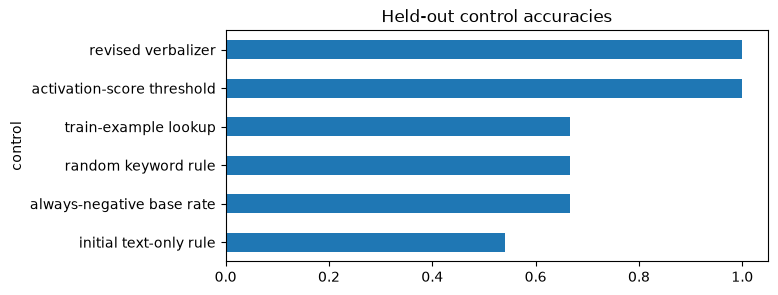

In [12]:
tests.test_control_table_revised_beats_text_random_and_lookup_controls(control_prediction_table)

control_rows = control_prediction_table(split.train, split.heldout, initial_rule, revised_rule)
controls_df = pd.DataFrame(control_rows)
display(controls_df)
controls_df.set_index("control")["accuracy"].plot(kind="barh", figsize=(7, 3), title="Held-out control accuracies")
plt.xlim(0, 1.05)
plt.show()

<details>
<summary>Solution</summary>

```python
def examples_only_lookup_predictions(
    train_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    test_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
) -> t.Tensor:
    """Predict positive only for exact held-out strings seen as positive in train."""

    positive_train_texts = {example.text for example in train_examples if example.label}
    return t.tensor([example.text in positive_train_texts for example in test_examples], dtype=t.bool)

def random_keyword_predictions(
    texts: list[str],
    *,
    seed: int = 0,
    k: int = 3,
) -> t.Tensor:
    """A deterministic random-keyword control over the observed text vocabulary."""

    if k <= 0:
        raise ValueError("k must be positive.")
    vocabulary = sorted({token for text in texts for token in _tokens(text)})
    if not vocabulary:
        raise ValueError("texts must contain at least one alphabetic token.")
    generator = t.Generator().manual_seed(seed)
    indices = t.randperm(len(vocabulary), generator=generator)[: min(k, len(vocabulary))]
    terms = [vocabulary[int(index.item())] for index in indices]
    return keyword_explanation_predictions(texts, terms)

def control_prediction_table(
    train_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    heldout_examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    initial_rule: ExplanationRule,
    revised_rule: ExplanationRule,
    *,
    seed: int = 0,
) -> tuple[dict[str, object], ...]:
    """Compare revised verbalizer predictions against non-explanatory controls."""

    heldout_texts = [example.text for example in heldout_examples]
    labels = t.tensor([example.label for example in heldout_examples], dtype=t.bool)
    initial_predictions = semantic_rule_predictions(heldout_texts, initial_rule)
    revised_predictions = semantic_rule_predictions(heldout_texts, revised_rule)
    always_negative = t.zeros_like(labels)
    random_predictions = random_keyword_predictions(heldout_texts, seed=seed, k=3)
    lookup_predictions = examples_only_lookup_predictions(train_examples, heldout_examples)
    train_scores = t.tensor([example.score for example in train_examples])
    train_labels = t.tensor([example.label for example in train_examples], dtype=t.bool)
    score_threshold = float((train_scores[train_labels].min() + train_scores[~train_labels].max()) / 2)
    score_predictions = t.tensor(
        [example.score >= score_threshold for example in heldout_examples],
        dtype=t.bool,
    )
    rows = [
        ("initial text-only rule", initial_predictions, "resting-word story from top examples"),
        ("always-negative base rate", always_negative, "majority-class baseline"),
        ("random keyword rule", random_predictions, "random words from held-out vocabulary"),
        ("train-example lookup", lookup_predictions, "exact memorization control"),
        ("activation-score threshold", score_predictions, "oracle-style feature-score upper bound"),
        ("revised verbalizer", revised_predictions, "semantic rule after counterexample revision"),
    ]
    revised_accuracy = _accuracy(revised_predictions, labels)
    return tuple(
        {
            "control": name,
            "accuracy": _accuracy(predictions, labels),
            "beats_revised": _accuracy(predictions, labels) > revised_accuracy,
            "notes": notes,
        }
        for name, predictions, notes in rows
    )
```

</details>

<details>
<summary>Interpreting the result</summary>

The revised rule should beat base-rate, random-word, and exact-lookup controls. The activation-score threshold is different: it is an oracle-style upper bound with direct access to the feature score, so matching it is evidence of compression rather than a baseline victory.

</details>


### Exercise - test the intervention direction

> ```yaml
> Difficulty: medium
> Importance: high
> ```

Held-out accuracy is still correlational. In the planted organism, the feature direction is the readout direction. Adding it by `alpha` should increase the feature score on examples the verbalizer predicts positive; adding an orthogonal random direction should not.

<details>
<summary>Expected output</summary>

With `alpha=1.25`, observed delta should be `1.25`, random-direction delta should be `0.0`, and the report should say the prediction matches and beats random.

</details>

<details>
<summary>Help - first useful hint</summary>

Use only predicted-positive examples for the sign test. Reject an all-negative verbalizer because it made no positive intervention prediction to test.

</details>

Common bug: taking absolute deltas. Directional verbalizers predict signs, so a large decrease is evidence against the explanation.


In [13]:
def intervention_prediction_report(
    baseline_scores: t.Tensor,
    intervened_scores: t.Tensor,
    *,
    predicted_direction: Literal["increase", "decrease"],
) -> InterventionPredictionReport:
    """Check whether an explanation predicts intervention direction."""

    baseline_mean = baseline_scores.float().mean().item()
    intervened_mean = intervened_scores.float().mean().item()
    observed_delta = intervened_mean - baseline_mean
    if predicted_direction == "increase":
        matches_prediction = observed_delta > 0
    elif predicted_direction == "decrease":
        matches_prediction = observed_delta < 0
    else:
        raise ValueError("predicted_direction must be 'increase' or 'decrease'.")
    return InterventionPredictionReport(
        predicted_direction=predicted_direction,
        observed_delta=observed_delta,
        matches_prediction=matches_prediction,
    )

def planted_intervention_direction_test(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    predictions: t.Tensor,
    *,
    alpha: float = 1.25,
) -> PlantedInterventionReport:
    """Exact toy intervention: adding the planted feature direction raises the readout score."""

    predictions = predictions.flatten().bool()
    if len(examples) != predictions.numel():
        raise ValueError("examples and predictions must have matching length.")
    if not predictions.any():
        raise ValueError("at least one example must be predicted positive for intervention scoring.")
    if alpha <= 0:
        raise ValueError("alpha must be positive.")
    scores = t.tensor([example.score for example in examples], dtype=t.float32)
    mask = predictions
    baseline_scores = scores[mask]
    intervened_scores = baseline_scores + alpha
    random_direction_scores = baseline_scores
    observed_delta = (intervened_scores.mean() - baseline_scores.mean()).item()
    random_delta = (random_direction_scores.mean() - baseline_scores.mean()).item()
    return PlantedInterventionReport(
        predicted_direction="increase",
        observed_delta=observed_delta,
        random_direction_delta=random_delta,
        matches_prediction=observed_delta > 0,
        beats_random_direction=observed_delta > abs(random_delta) + 0.5,
        evaluated_examples=int(mask.sum().item()),
    )

In [14]:
tests.test_intervention_prediction_checks_signed_direction(intervention_prediction_report)
tests.test_intervention_prediction_rejects_invalid_direction(intervention_prediction_report)
tests.test_planted_intervention_direction_beats_random_direction(planted_intervention_direction_test)

heldout_texts = [example.text for example in split.heldout]
revised_predictions = semantic_rule_predictions(heldout_texts, revised_rule)
intervention_report = planted_intervention_direction_test(split.heldout, revised_predictions)
print(intervention_report)

All tests in `test_intervention_prediction_checks_signed_direction` passed!
All tests in `test_intervention_prediction_rejects_invalid_direction` passed!
All tests in `test_planted_intervention_direction_beats_random_direction` passed!
PlantedInterventionReport(predicted_direction='increase', observed_delta=1.25, random_direction_delta=0.0, matches_prediction=True, beats_random_direction=True, evaluated_examples=8)


<details>
<summary>Solution</summary>

```python
def intervention_prediction_report(
    baseline_scores: t.Tensor,
    intervened_scores: t.Tensor,
    *,
    predicted_direction: Literal["increase", "decrease"],
) -> InterventionPredictionReport:
    """Check whether an explanation predicts intervention direction."""

    baseline_mean = baseline_scores.float().mean().item()
    intervened_mean = intervened_scores.float().mean().item()
    observed_delta = intervened_mean - baseline_mean
    if predicted_direction == "increase":
        matches_prediction = observed_delta > 0
    elif predicted_direction == "decrease":
        matches_prediction = observed_delta < 0
    else:
        raise ValueError("predicted_direction must be 'increase' or 'decrease'.")
    return InterventionPredictionReport(
        predicted_direction=predicted_direction,
        observed_delta=observed_delta,
        matches_prediction=matches_prediction,
    )

def planted_intervention_direction_test(
    examples: tuple[PlantedFeatureExample, ...] | list[PlantedFeatureExample],
    predictions: t.Tensor,
    *,
    alpha: float = 1.25,
) -> PlantedInterventionReport:
    """Exact toy intervention: adding the planted feature direction raises the readout score."""

    predictions = predictions.flatten().bool()
    if len(examples) != predictions.numel():
        raise ValueError("examples and predictions must have matching length.")
    if not predictions.any():
        raise ValueError("at least one example must be predicted positive for intervention scoring.")
    if alpha <= 0:
        raise ValueError("alpha must be positive.")
    scores = t.tensor([example.score for example in examples], dtype=t.float32)
    mask = predictions
    baseline_scores = scores[mask]
    intervened_scores = baseline_scores + alpha
    random_direction_scores = baseline_scores
    observed_delta = (intervened_scores.mean() - baseline_scores.mean()).item()
    random_delta = (random_direction_scores.mean() - baseline_scores.mean()).item()
    return PlantedInterventionReport(
        predicted_direction="increase",
        observed_delta=observed_delta,
        random_direction_delta=random_delta,
        matches_prediction=observed_delta > 0,
        beats_random_direction=observed_delta > abs(random_delta) + 0.5,
        evaluated_examples=int(mask.sum().item()),
    )
```

</details>

<details>
<summary>Interpreting the result</summary>

The sign check adds causal evidence inside this planted organism: moving along the known feature direction changes the readout as predicted, while an orthogonal direction does not. It does not prove that every natural-language description identifies a causal feature in a real transformer.

</details>


### Exercise - build the signature result table

> ```yaml
> Difficulty: medium
> Importance: high
> ```

Bundle the full CPU result: example selection, initial rule, counterexample mining, revised rule, held-out rows, controls, intervention, and brevity. The result should be visible as a table and plot, not a loaded verification report.

<details>
<summary>Expected output</summary>

`signature_passed == True`; revised accuracy `1.0`; initial accuracy below `0.75`; contrastive accuracy `1.0`; intervention delta `1.25`; random-direction delta `0.0`; at least 20 held-out rows are visible.

</details>

<details>
<summary>Help - first useful hint</summary>

Make the table carry the actual prompts. If you cannot inspect examples, you cannot tell whether a verbalizer is meaningful or just exploiting leakage.

</details>

Common bug: printing only a dict of metrics. ARENA-style verification should leave behind interpretable examples, controls, and failure cases.


In [15]:
def explanation_brevity_report(
    explanation: str,
    examples: list[str] | tuple[str, ...],
) -> ExplanationBrevityReport:
    """Check whether an explanation is shorter than an examples-only baseline."""

    explanation_word_count = len(explanation.split())
    examples_word_count = sum(len(example.split()) for example in examples)
    return ExplanationBrevityReport(
        explanation_word_count=explanation_word_count,
        examples_word_count=examples_word_count,
        shorter_than_examples=explanation_word_count < examples_word_count,
    )

def run_planted_feature_verbalizer_signature_result(seed: int = 0) -> dict:
    """Run the full CPU signature result on the exact planted verbalizer organism."""

    dataset = make_planted_feature_dataset()
    split = split_planted_feature_dataset(dataset)
    train_texts = [example.text for example in split.train]
    train_scores = t.tensor([example.score for example in split.train], dtype=t.float32)
    train_labels = t.tensor([example.label for example in split.train], dtype=t.bool)
    train_threshold = float((train_scores[train_labels].min() + train_scores[~train_labels].max()) / 2)
    example_set = gather_verbalizer_examples(
        train_texts,
        train_scores,
        train_labels,
        k=4,
        threshold=train_threshold,
        seed=seed,
    )

    initial_rule = ExplanationRule(
        description="feature fires on resting words",
        required_groups=("resting",),
    )
    revision_texts = [example.text for example in split.revision]
    revision_labels = t.tensor([example.label for example in split.revision], dtype=t.bool)
    revision_predictions = semantic_rule_predictions(revision_texts, initial_rule)
    counterexamples = mine_counterexamples(split.revision, revision_predictions, max_examples=8)
    revised_rule = revise_rule_from_counterexamples(initial_rule, counterexamples)

    heldout_texts = [example.text for example in split.heldout]
    heldout_labels = t.tensor([example.label for example in split.heldout], dtype=t.bool)
    initial_predictions = semantic_rule_predictions(heldout_texts, initial_rule)
    revised_predictions = semantic_rule_predictions(heldout_texts, revised_rule)
    contrastive_mask = t.tensor(
        [example.counterfactual_type not in {"positive", "irrelevant"} for example in split.heldout],
        dtype=t.bool,
    )
    prediction_report = explanation_prediction_report(
        revised_predictions,
        heldout_labels,
        initial_predictions,
        contrastive_mask,
    )
    controls = control_prediction_table(
        split.train,
        split.heldout,
        initial_rule,
        revised_rule,
        seed=seed,
    )
    intervention = planted_intervention_direction_test(split.heldout, revised_predictions)
    brevity = explanation_brevity_report(
        revised_rule.description,
        [example.text for example in example_set.top],
    )
    revised_accuracy = prediction_report.accuracy
    control_accuracies = {
        str(row["control"]): float(row["accuracy"])
        for row in controls
        if row["control"] != "activation-score threshold"
    }
    signature_passed = (
        revised_accuracy >= 0.95
        and all(revised_accuracy > value for value in control_accuracies.values() if value < 0.999)
        and prediction_report.survives_contrastive
        and len(counterexamples) >= 3
        and intervention.matches_prediction
        and intervention.beats_random_direction
        and brevity.shorter_than_examples
    )
    return {
        "claim": (
            "On an exact planted feature, a revised semantic verbalizer predicts held-out "
            "counterfactual activations and the sign of a feature-direction intervention."
        ),
        "planted_rule": "living animal + resting verb + physical surface - decoy object terms",
        "train_count": len(split.train),
        "revision_count": len(split.revision),
        "heldout_count": len(split.heldout),
        "initial_rule": initial_rule.__dict__,
        "revised_rule": revised_rule.__dict__,
        "example_groups": {
            "top": [example.__dict__ for example in example_set.top],
            "bottom": [example.__dict__ for example in example_set.bottom],
            "random": [example.__dict__ for example in example_set.random],
            "contrastive": [example.__dict__ for example in example_set.contrastive],
        },
        "validation_counterexamples": list(counterexamples),
        "heldout_rows": [
            {
                "text": example.text,
                "score": example.score,
                "label": example.label,
                "initial_prediction": bool(initial),
                "revised_prediction": bool(revised),
                "counterfactual_type": example.counterfactual_type,
            }
            for example, initial, revised in zip(
                split.heldout,
                initial_predictions.tolist(),
                revised_predictions.tolist(),
                strict=True,
            )
        ],
        "control_table": list(controls),
        "metrics": {
            "initial_accuracy": _accuracy(initial_predictions, heldout_labels),
            "revised_accuracy": prediction_report.accuracy,
            "baseline_accuracy": prediction_report.baseline_accuracy,
            "contrastive_accuracy": prediction_report.contrastive_accuracy,
            "passes_baseline": prediction_report.passes_baseline,
            "survives_contrastive": prediction_report.survives_contrastive,
            "counterexamples_mined": len(counterexamples),
            "intervention_delta": intervention.observed_delta,
            "random_direction_delta": intervention.random_direction_delta,
            "intervention_matches_prediction": intervention.matches_prediction,
            "target_beats_random_direction": intervention.beats_random_direction,
            "brevity_shorter_than_examples": brevity.shorter_than_examples,
        },
        "intervention": intervention.__dict__,
        "brevity": brevity.__dict__,
        "signature_passed": signature_passed,
    }

def example_selection_smoke_test() -> dict:
    texts = ["alpha code", "beta def", "plain story", "quiet notes"]
    scores = t.tensor([0.9, 0.8, 0.2, 0.1])
    labels = t.tensor([1, 1, 0, 0], dtype=t.bool)
    examples = gather_verbalizer_examples(texts, scores, labels, k=2, threshold=0.5, seed=0)
    return {
        "top": [example.text for example in examples.top],
        "bottom": [example.text for example in examples.bottom],
        "random": [example.text for example in examples.random],
        "contrastive": [example.text for example in examples.contrastive],
    }

def prediction_report_smoke_test() -> dict:
    texts = ["write code", "plain story", "def fn", "quiet notes"]
    labels = t.tensor([1, 0, 1, 0], dtype=t.bool)
    predictions = keyword_explanation_predictions(texts, ["code", "def"])
    baseline = t.zeros(4, dtype=t.bool)
    contrastive_mask = t.tensor([False, False, True, True])
    report = explanation_prediction_report(predictions, labels, baseline, contrastive_mask)
    return {"predictions": predictions.tolist(), **report.__dict__}

def counterexample_revision_smoke_test() -> dict:
    texts = ["write code", "plain story", "def fn", "quiet notes"]
    predictions = t.tensor([1, 1, 1, 0], dtype=t.bool)
    labels = t.tensor([1, 0, 1, 0], dtype=t.bool)
    report = find_counterexamples(texts, predictions, labels)
    revised = revise_explanation(
        "Feature activates on code.",
        report.counterexamples,
        revision_note="Exclude ordinary stories.",
    )
    return {
        "num_counterexamples": report.num_counterexamples,
        "counterexamples": list(report.counterexamples),
        "revised": revised,
    }

def intervention_prediction_smoke_test() -> dict:
    baseline = t.tensor([0.1, 0.2])
    intervened = t.tensor([0.5, 0.6])
    return intervention_prediction_report(
        baseline,
        intervened,
        predicted_direction="increase",
    ).__dict__

def brevity_smoke_test() -> dict:
    explanation = "Activates on code snippets."
    examples = ["write python code", "define a function with def"]
    return explanation_brevity_report(explanation, examples).__dict__

def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    return {
        "examples": example_selection_smoke_test(),
        "prediction": prediction_report_smoke_test(),
        "counterexamples": counterexample_revision_smoke_test(),
        "intervention": intervention_prediction_smoke_test(),
        "brevity": brevity_smoke_test(),
        "planted_signature": run_planted_feature_verbalizer_signature_result(seed=0),
    }

In [16]:
tests.test_explanation_brevity_compares_against_examples_only_baseline(explanation_brevity_report)
tests.test_planted_signature_result_contains_visible_evidence(
    run_planted_feature_verbalizer_signature_result,
)
tests.test_notebook_contract(run_smoke_test)

signature_result = run_planted_feature_verbalizer_signature_result(seed=0)
print(signature_result["claim"])
display(pd.DataFrame(signature_result["control_table"]))
display(pd.DataFrame(signature_result["heldout_rows"]))

All tests in `test_explanation_brevity_compares_against_examples_only_baseline` passed!
All tests in `test_planted_signature_result_contains_visible_evidence` passed!
All tests in `test_notebook_contract` passed!
On an exact planted feature, a revised semantic verbalizer predicts held-out counterfactual activations and the sign of a feature-direction intervention.


,control,accuracy,beats_revised,notes
0,initial text-only rule,0.541667,False,resting-word story from top examples
1,always-negative base rate,0.666667,False,majority-class baseline
2,random keyword rule,0.666667,False,random words from held-out vocabulary
3,train-example lookup,0.666667,False,exact memorization control
4,activation-score threshold,1.000000,False,oracle-style feature-score upper bound
5,revised verbalizer,1.000000,False,semantic rule after counterexample revision


,text,score,label,initial_prediction,revised_prediction,counterfactual_type
0,The horse rested on the blanket.,4.60,True,True,True,positive
1,A lizard dozed on the warm rock.,4.57,True,True,True,positive
2,The owl perched on the branch.,4.60,True,True,True,positive
3,The kitten slept beside the basket.,4.65,True,True,True,positive
4,The puppy lounged on the couch.,4.53,True,True,True,positive
5,An alpaca sat near the fence.,4.60,True,True,True,positive
6,The bear rested by the log.,4.52,True,True,True,positive
7,The sheep slept on the hay.,4.65,True,True,True,positive
8,The toy horse rested on the blanket.,0.06,False,True,False,decoy_animal
9,A ceramic lizard dozed on the rock.,-0.07,False,True,False,decoy_animal


<details>
<summary>Solution</summary>

```python
def explanation_brevity_report(
    explanation: str,
    examples: list[str] | tuple[str, ...],
) -> ExplanationBrevityReport:
    """Check whether an explanation is shorter than an examples-only baseline."""

    explanation_word_count = len(explanation.split())
    examples_word_count = sum(len(example.split()) for example in examples)
    return ExplanationBrevityReport(
        explanation_word_count=explanation_word_count,
        examples_word_count=examples_word_count,
        shorter_than_examples=explanation_word_count < examples_word_count,
    )

def run_planted_feature_verbalizer_signature_result(seed: int = 0) -> dict:
    """Run the full CPU signature result on the exact planted verbalizer organism."""

    dataset = make_planted_feature_dataset()
    split = split_planted_feature_dataset(dataset)
    train_texts = [example.text for example in split.train]
    train_scores = t.tensor([example.score for example in split.train], dtype=t.float32)
    train_labels = t.tensor([example.label for example in split.train], dtype=t.bool)
    train_threshold = float((train_scores[train_labels].min() + train_scores[~train_labels].max()) / 2)
    example_set = gather_verbalizer_examples(
        train_texts,
        train_scores,
        train_labels,
        k=4,
        threshold=train_threshold,
        seed=seed,
    )

    initial_rule = ExplanationRule(
        description="feature fires on resting words",
        required_groups=("resting",),
    )
    revision_texts = [example.text for example in split.revision]
    revision_labels = t.tensor([example.label for example in split.revision], dtype=t.bool)
    revision_predictions = semantic_rule_predictions(revision_texts, initial_rule)
    counterexamples = mine_counterexamples(split.revision, revision_predictions, max_examples=8)
    revised_rule = revise_rule_from_counterexamples(initial_rule, counterexamples)

    heldout_texts = [example.text for example in split.heldout]
    heldout_labels = t.tensor([example.label for example in split.heldout], dtype=t.bool)
    initial_predictions = semantic_rule_predictions(heldout_texts, initial_rule)
    revised_predictions = semantic_rule_predictions(heldout_texts, revised_rule)
    contrastive_mask = t.tensor(
        [example.counterfactual_type not in {"positive", "irrelevant"} for example in split.heldout],
        dtype=t.bool,
    )
    prediction_report = explanation_prediction_report(
        revised_predictions,
        heldout_labels,
        initial_predictions,
        contrastive_mask,
    )
    controls = control_prediction_table(
        split.train,
        split.heldout,
        initial_rule,
        revised_rule,
        seed=seed,
    )
    intervention = planted_intervention_direction_test(split.heldout, revised_predictions)
    brevity = explanation_brevity_report(
        revised_rule.description,
        [example.text for example in example_set.top],
    )
    revised_accuracy = prediction_report.accuracy
    control_accuracies = {
        str(row["control"]): float(row["accuracy"])
        for row in controls
        if row["control"] != "activation-score threshold"
    }
    signature_passed = (
        revised_accuracy >= 0.95
        and all(revised_accuracy > value for value in control_accuracies.values() if value < 0.999)
        and prediction_report.survives_contrastive
        and len(counterexamples) >= 3
        and intervention.matches_prediction
        and intervention.beats_random_direction
        and brevity.shorter_than_examples
    )
    return {
        "claim": (
            "On an exact planted feature, a revised semantic verbalizer predicts held-out "
            "counterfactual activations and the sign of a feature-direction intervention."
        ),
        "planted_rule": "living animal + resting verb + physical surface - decoy object terms",
        "train_count": len(split.train),
        "revision_count": len(split.revision),
        "heldout_count": len(split.heldout),
        "initial_rule": initial_rule.__dict__,
        "revised_rule": revised_rule.__dict__,
        "example_groups": {
            "top": [example.__dict__ for example in example_set.top],
            "bottom": [example.__dict__ for example in example_set.bottom],
            "random": [example.__dict__ for example in example_set.random],
            "contrastive": [example.__dict__ for example in example_set.contrastive],
        },
        "validation_counterexamples": list(counterexamples),
        "heldout_rows": [
            {
                "text": example.text,
                "score": example.score,
                "label": example.label,
                "initial_prediction": bool(initial),
                "revised_prediction": bool(revised),
                "counterfactual_type": example.counterfactual_type,
            }
            for example, initial, revised in zip(
                split.heldout,
                initial_predictions.tolist(),
                revised_predictions.tolist(),
                strict=True,
            )
        ],
        "control_table": list(controls),
        "metrics": {
            "initial_accuracy": _accuracy(initial_predictions, heldout_labels),
            "revised_accuracy": prediction_report.accuracy,
            "baseline_accuracy": prediction_report.baseline_accuracy,
            "contrastive_accuracy": prediction_report.contrastive_accuracy,
            "passes_baseline": prediction_report.passes_baseline,
            "survives_contrastive": prediction_report.survives_contrastive,
            "counterexamples_mined": len(counterexamples),
            "intervention_delta": intervention.observed_delta,
            "random_direction_delta": intervention.random_direction_delta,
            "intervention_matches_prediction": intervention.matches_prediction,
            "target_beats_random_direction": intervention.beats_random_direction,
            "brevity_shorter_than_examples": brevity.shorter_than_examples,
        },
        "intervention": intervention.__dict__,
        "brevity": brevity.__dict__,
        "signature_passed": signature_passed,
    }

def example_selection_smoke_test() -> dict:
    texts = ["alpha code", "beta def", "plain story", "quiet notes"]
    scores = t.tensor([0.9, 0.8, 0.2, 0.1])
    labels = t.tensor([1, 1, 0, 0], dtype=t.bool)
    examples = gather_verbalizer_examples(texts, scores, labels, k=2, threshold=0.5, seed=0)
    return {
        "top": [example.text for example in examples.top],
        "bottom": [example.text for example in examples.bottom],
        "random": [example.text for example in examples.random],
        "contrastive": [example.text for example in examples.contrastive],
    }

def prediction_report_smoke_test() -> dict:
    texts = ["write code", "plain story", "def fn", "quiet notes"]
    labels = t.tensor([1, 0, 1, 0], dtype=t.bool)
    predictions = keyword_explanation_predictions(texts, ["code", "def"])
    baseline = t.zeros(4, dtype=t.bool)
    contrastive_mask = t.tensor([False, False, True, True])
    report = explanation_prediction_report(predictions, labels, baseline, contrastive_mask)
    return {"predictions": predictions.tolist(), **report.__dict__}

def counterexample_revision_smoke_test() -> dict:
    texts = ["write code", "plain story", "def fn", "quiet notes"]
    predictions = t.tensor([1, 1, 1, 0], dtype=t.bool)
    labels = t.tensor([1, 0, 1, 0], dtype=t.bool)
    report = find_counterexamples(texts, predictions, labels)
    revised = revise_explanation(
        "Feature activates on code.",
        report.counterexamples,
        revision_note="Exclude ordinary stories.",
    )
    return {
        "num_counterexamples": report.num_counterexamples,
        "counterexamples": list(report.counterexamples),
        "revised": revised,
    }

def intervention_prediction_smoke_test() -> dict:
    baseline = t.tensor([0.1, 0.2])
    intervened = t.tensor([0.5, 0.6])
    return intervention_prediction_report(
        baseline,
        intervened,
        predicted_direction="increase",
    ).__dict__

def brevity_smoke_test() -> dict:
    explanation = "Activates on code snippets."
    examples = ["write python code", "define a function with def"]
    return explanation_brevity_report(explanation, examples).__dict__

def run_smoke_test(cpu: bool = True) -> dict:
    _ = cpu
    return {
        "examples": example_selection_smoke_test(),
        "prediction": prediction_report_smoke_test(),
        "counterexamples": counterexample_revision_smoke_test(),
        "intervention": intervention_prediction_smoke_test(),
        "brevity": brevity_smoke_test(),
        "planted_signature": run_planted_feature_verbalizer_signature_result(seed=0),
    }
```

</details>

<details>
<summary>Interpreting the result</summary>

No single number carries the claim. The result needs the control gap, the actual held-out prompts, the counterexample categories, and the signed intervention together. That bundle shows both where the first story failed and what evidence the revision earned.

</details>


## Signature Result

Run the next cell to recompute the result from your own implementations. It must show three linked pieces of evidence: the revised verbalizer against controls, the score/label structure of every held-out counterfactual, and the signed feature-direction intervention against an orthogonal direction. The static image is only a preview of the expected composition; the tables and plot below are the graded result.

![Feature verbalizer planted signature](../../instructions/assets/feature_verbalizers_planted_signature.png)


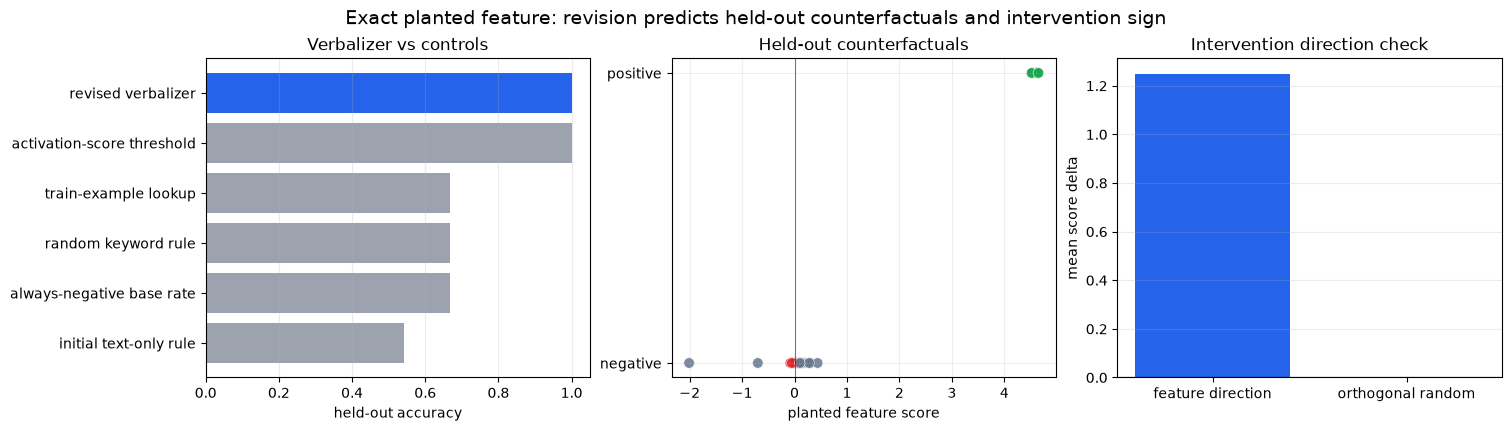

,control,accuracy,beats_revised,notes
0,initial text-only rule,0.541667,False,resting-word story from top examples
1,always-negative base rate,0.666667,False,majority-class baseline
2,random keyword rule,0.666667,False,random words from held-out vocabulary
3,train-example lookup,0.666667,False,exact memorization control
4,activation-score threshold,1.000000,False,oracle-style feature-score upper bound
5,revised verbalizer,1.000000,False,semantic rule after counterexample revision


,text,counterfactual_type,score,label,initial_prediction,revised_prediction
0,The horse rested on the blanket.,positive,4.60,True,True,True
1,A lizard dozed on the warm rock.,positive,4.57,True,True,True
2,The owl perched on the branch.,positive,4.60,True,True,True
3,The kitten slept beside the basket.,positive,4.65,True,True,True
4,The puppy lounged on the couch.,positive,4.53,True,True,True
5,An alpaca sat near the fence.,positive,4.60,True,True,True
6,The bear rested by the log.,positive,4.52,True,True,True
7,The sheep slept on the hay.,positive,4.65,True,True,True
8,The toy horse rested on the blanket.,decoy_animal,0.06,False,True,False
9,A ceramic lizard dozed on the rock.,decoy_animal,-0.07,False,True,False


In [17]:
# Recompute the signature result from the functions you implemented above.
signature_result = run_planted_feature_verbalizer_signature_result(seed=0)
controls_df = pd.DataFrame(signature_result["control_table"])
heldout_df = pd.DataFrame(signature_result["heldout_rows"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
control_colors = [
    "#2563eb" if name == "revised verbalizer" else "#9ca3af"
    for name in controls_df["control"]
]
axes[0].barh(controls_df["control"], controls_df["accuracy"], color=control_colors)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("held-out accuracy")
axes[0].set_title("Verbalizer vs controls")
axes[0].grid(axis="x", alpha=0.25)

point_colors = heldout_df["counterfactual_type"].map(
    lambda kind: "#16a34a" if kind == "positive" else ("#dc2626" if kind == "decoy_animal" else "#64748b")
)
axes[1].scatter(
    heldout_df["score"],
    heldout_df["label"].astype(int),
    c=point_colors,
    s=58,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
axes[1].axvline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_yticks([0, 1], ["negative", "positive"])
axes[1].set_xlabel("planted feature score")
axes[1].set_title("Held-out counterfactuals")
axes[1].grid(alpha=0.2)

axes[2].bar(
    ["feature direction", "orthogonal random"],
    [
        signature_result["intervention"]["observed_delta"],
        signature_result["intervention"]["random_direction_delta"],
    ],
    color=["#2563eb", "#9ca3af"],
)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("mean score delta")
axes[2].set_title("Intervention direction check")
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Exact planted feature: revision predicts held-out counterfactuals and intervention sign",
    fontsize=14,
)
plt.show()

display(controls_df)
display(
    heldout_df[
        [
            "text",
            "counterfactual_type",
            "score",
            "label",
            "initial_prediction",
            "revised_prediction",
        ]
    ]
)


## Real Transformer Escalation

The planted organism is the proof surface for the exercises. The parent CUDA pass escalates the same validation loop to a pinned TransformerLens `gelu-1l` residual direction: anchor prompts define a real residual direction at `blocks.0.hook_resid_post`, train prompts produce top/bottom/contrastive examples, held-out prompts test the learned verbalizer terms, and adding the target direction is compared against an orthogonal random direction.

This cell is intentionally not run in the CPU notebook execution. It is the CUDA handoff point, not a fallback.


In [18]:
def load_verification_evidence() -> dict:
    report = json.loads((section_dir / "verification_report.json").read_text())
    required = {"accepted", "metrics", "gt_tier", "notebook_id"}
    missing = sorted(required - report.keys())
    if missing:
        raise ValueError(f"verification report is missing required fields: {missing}")
    return report


def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    from importlib import import_module

    verification = import_module("chapter7_activation_to_language.exercises.part2_feature_verbalizers.solutions")
    return verification.run_gpu_test(max_vram_gb=max_vram_gb)


def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return run_gpu_test(max_vram_gb=max_vram_gb)


# Deliberately do not call the GPU entry points during CPU notebook execution.


## Try It Yourself

Edit the prompt list or the rule below. A good change should make a concrete prediction before you run it: which examples become false positives, which become false negatives, and whether the intervention sign is still meaningful?


In [19]:
custom_prompts = [
    "The plastic fox rested on the ledge.",
    "The badger curled on the pillow.",
    "The catalog rested on the shelf.",
]
custom_rule = ExplanationRule(
    description="animal resting on a surface, excluding known decoys",
    required_groups=("animal", "resting", "surface"),
    excluded_terms=tuple(sorted(DECOY_TERMS)),
)
custom_predictions = semantic_rule_predictions(custom_prompts, custom_rule)
display(pd.DataFrame({"prompt": custom_prompts, "prediction": custom_predictions.tolist()}))

,prompt,prediction
0,The plastic fox rested on the ledge.,False
1,The badger curled on the pillow.,True
2,The catalog rested on the shelf.,False


## Bonus: Hunt an Anomaly

Try to break the revised rule without changing the hidden oracle. Some good attacks: add a new decoy word not in `DECOY_TERMS`, use an animal synonym missing from `ANIMAL_TERMS`, or write a prompt where the grammar implies the animal is not actually resting on the named surface. If your rule breaks, write down whether this is a lexicon problem, a parsing problem, or a limitation of keyword verbalizers.


## Interpreting the Result

The planted result is strong because the ground truth is exact: the revised verbalizer reaches `1.0` final held-out accuracy on 24 counterfactual prompts, beats text-only, random-word, base-rate, and lookup controls, and predicts the positive feature-direction intervention. The score-threshold upper bound also reaches `1.0`, which is expected because it can see the planted feature score directly. This is a model-organism result, not a claim that keyword verbalizers solve arbitrary SAE or neuron explanation.

## Limitations

The pinned `gelu-1l` path is deliberately narrower. It validates one residual direction from a small public transformer with safe prompts. It does not claim API-LLM explanation quality, SAE-feature generality, broad natural-language parsing, robust OOD behavior, or that a concise correlation-based explanation identifies a complete causal mechanism. The CUDA escalation must still be rerun after this rewrite before release evidence is refreshed.

## Reading Links

- [Bills et al., *Language models can explain neurons in language models*](https://openaipublic.blob.core.windows.net/neuron-explainer/paper/index.html) introduces the explain-simulate-score loop and keeps explanation and simulation documents separate.
- [Bricken et al., *Towards Monosemanticity*](https://transformer-circuits.pub/2023/monosemantic-features/index.html) applies held-out activation prediction to learned SAE features and explicitly guards against leaking activation information to the simulator.
- [Pinned `gelu-1l` checkpoint](https://huggingface.co/NeelNanda/GELU_1L512W_C4_Code/tree/bddc0e332f0ae84279e6a6a45d91b314899e1603) is the small real-transformer escalation used by the serialized CUDA verification path.
